# Image Processing

# Pillow

In [143]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


# Importing Image

In [156]:
scis1 = Image.open('../data/scis1.jpeg')
scis2 = Image.open('../data/scis2.jpeg')

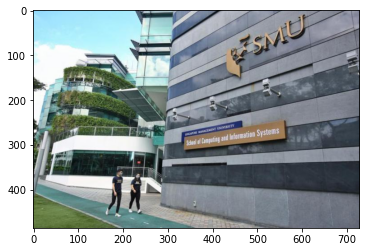

In [157]:
plt.imshow(scis1)
plt.show()

## Common Operations

In [161]:
# Resize
scis1_sm = scis1.resize((360, 240))

print(f"Original size: {scis1.size}")
print(f"New size: {scis1_sm.size}")

Original size: (729, 486)
New size: (360, 240)


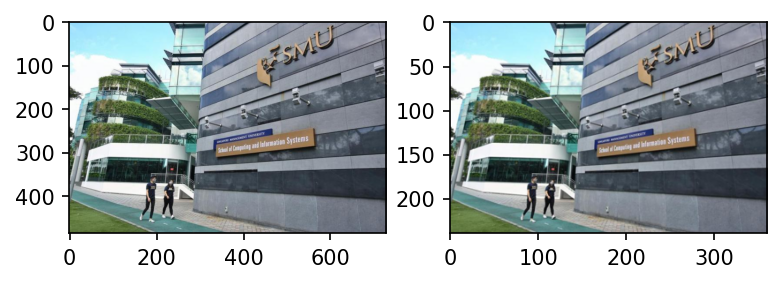

In [162]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(scis1)
axs[1].imshow(scis1_sm)

fig.set_dpi(150)
plt.show()

## Gray Scale Image

In [8]:
gray = np.array(scis1.convert('L'))  # L for luminance (https://pillow.readthedocs.io/en/stable/handbook/concepts.html#concept-modes)
print(f'Shape: {gray.shape}, Data Type: {gray.dtype}')

Shape: (240, 360), Data Type: uint8


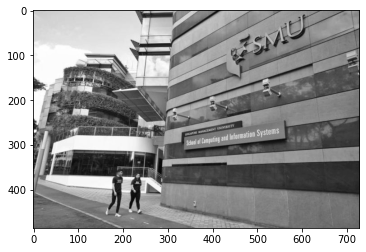

In [164]:
plt.imshow(gray)
plt.gray()
plt.show()

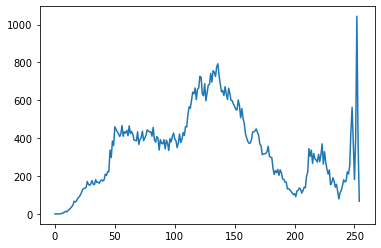

In [9]:
histogram, bins = np.histogram(gray, bins=255, range=(0, 255))
plt.plot(bins[:-1], histogram)
plt.show()

## RGB Image and Histogram

In [165]:
a = np.array(scis1)
print(f'Shape: {a.shape}, Data Type: {a.dtype}')

Shape: (486, 729, 3), Data Type: uint8


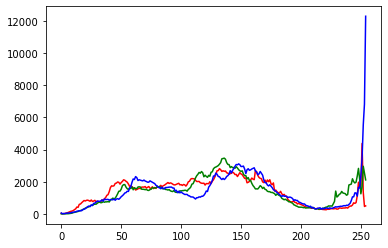

In [166]:
hist_r, bins = np.histogram(a[:,:,0], bins=255, range=(0, 255))
hist_g, bins = np.histogram(a[:,:,1], bins=255, range=(0, 255))
hist_b, bins = np.histogram(a[:,:,2], bins=255, range=(0, 255))
plt.plot(bins[:-1], hist_r, color='r')
plt.plot(bins[:-1], hist_g, color='g')
plt.plot(bins[:-1], hist_b, color='b')
plt.show()

## Filters

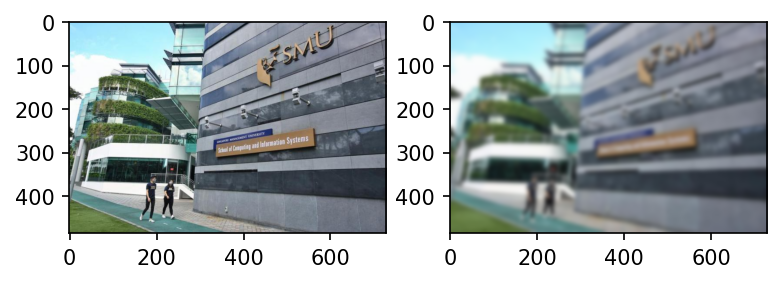

In [167]:
# Gaussian Filter
from scipy.ndimage import gaussian_filter

a1 = np.array(scis1)
a2 = gaussian_filter(a1, sigma=(5, 5, 0))

fig, axs = plt.subplots(1, 2)
fig.set_dpi(150)
axs[0].imshow(a1)
axs[1].imshow(a2)

plt.show()

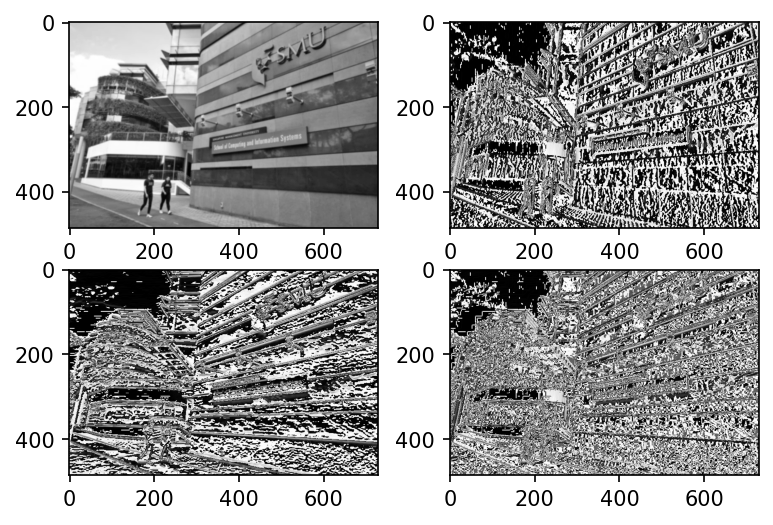

In [168]:
# Sobel filter
# https://scipy-lectures.org/advanced/image_processing/auto_examples/plot_find_edges.html
from scipy.ndimage import sobel, laplace

gray = np.array(scis1.convert('L'))
gray = gaussian_filter(gray, sigma=(1,1))

fig, axs = plt.subplots(2, 2)
fig.set_dpi(150)
plt.gray()


sl = laplace(gray)
sx = sobel(gray, axis=1)
sy = sobel(gray, axis=0)
sob = np.hypot(sx, sy).astype('uint8')

axs[0, 0].imshow(gray)
axs[0, 1].imshow(sx)
axs[1, 0].imshow(sy)
axs[1, 1].imshow(sob)

plt.show()


# Local Image Descriptor

# Feature Matching and Homography

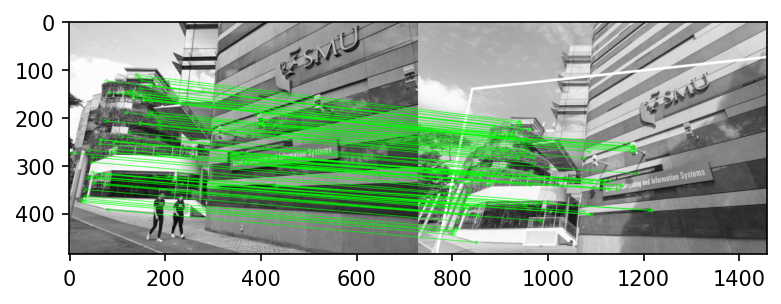

In [24]:
# https://docs.opencv.org/4.5.5/d1/de0/tutorial_py_feature_homography.html

import numpy as np
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('../data/scis1.jpeg',cv2.IMREAD_GRAYSCALE)          # queryImage
img2 = cv2.imread('../data/scis2.jpeg', cv2.IMREAD_GRAYSCALE) # trainImage

# Initiate SIFT detector
sift = cv2.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# BFMatcher with default params
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2,k=2)

# Apply ratio test
good = []
for m,n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)


#
src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
matchesMask = mask.ravel().tolist()

h,w = img1.shape
pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1,1,2)
dst = cv2.perspectiveTransform(pts, M)
img2 = cv2.polylines(img2,[np.int32(dst)],True,255,3, cv2.LINE_AA)

draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2)

img3 = cv2.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)

plt.figure(dpi=150)
plt.imshow(img3)
plt.show()

# Warping Image

In [112]:
# https://docs.opencv.org/4.x/da/d6e/tutorial_py_geometric_transformations.html
dst = cv2.warpPerspective(img1, M, img2.shape[::-1])

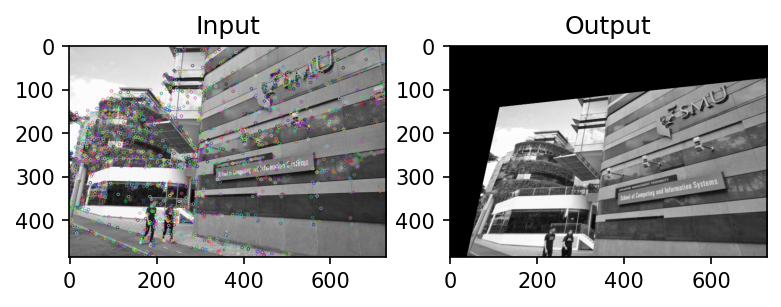

In [113]:
plt.figure(dpi=150)
plt.subplot(121)
plt.imshow(img)
plt.title('Input')

plt.subplot(122)
plt.imshow(dst, cmap='gray')
plt.title('Output')
plt.show()

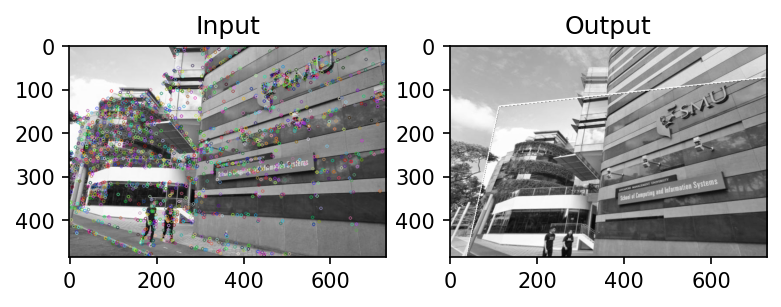

In [115]:
dst[dst == 0] = img2[dst == 0]
plt.figure(dpi=150)
plt.subplot(121)
plt.imshow(img)
plt.title('Input')

plt.subplot(122)
plt.imshow(dst, cmap='gray')
plt.title('Output')
plt.show()

In [116]:
pts1 = np.squeeze(src_pts)
pts2 = np.squeeze(dst_pts)

pts1 = np.array([(p[0], p[1], 1) for p in pts1])
pts2 = np.array([(p[0], p[1], 1) for p in pts2])

In [117]:
H = np.linalg.lstsq(pts1, pts2)[0]

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_68083/3659743904.py:1: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  H = np.linalg.lstsq(pts1, pts2)[0]


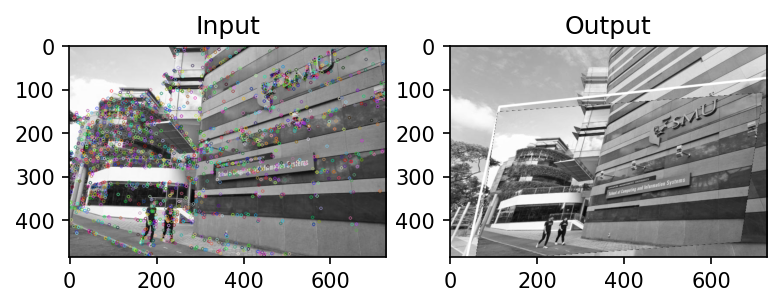

In [119]:
# https://docs.opencv.org/4.x/da/d6e/tutorial_py_geometric_transformations.html
dst = cv2.warpPerspective(img1, H.T, img2.shape[::-1])
dst[dst == 0] = img2[dst == 0]
plt.figure(dpi=150)
plt.subplot(121)
plt.imshow(img)
plt.title('Input')

plt.subplot(122)
plt.imshow(dst, cmap='gray')
plt.title('Output')
plt.show()

In [140]:
def H_from_points(fp, tp):
    m = np.mean(fp[:2], axis=1)
    maxstd = np.max(np.std(fp[:2], axis=1)) + 1e-9
    C1 = np.diag([1/maxstd, 1/maxstd, 1])
    C1[0][2] = -m[0] / maxstd
    C1[1][2] = -m[1] / maxstd
    fp = np.dot(C1, fp)

    m = np.mean(tp[:2], axis=1)
    maxstd = np.max(np.std(tp[:2], axis=1)) + 1e-9
    C2 = np.diag([1/maxstd, 1/maxstd, 1])
    C2[0][2] = -m[0] / maxstd
    C2[1][2] = -m[1] / maxstd
    tp = np.dot(C2, tp)

    nbr_correspondences = fp.shape[1]
    A = np.zeros((2 * nbr_correspondences, 9))
    for i in range(nbr_correspondences):
        A[2*i] = [-fp[0][i], -fp[1][i], -1, 0, 0, 0, tp[0][i] * fp[0][i], tp[0][i] * fp[1][i], tp[0][i]]
        A[2 * i+1] = [0, 0, 0, -fp[0][i], -fp[1][i], -1, tp[1][i] * fp[0][i], tp[1][i] * fp[1][i], tp[1][i]]

    U, S, V = np.linalg.svd(A)
    H = V[8].reshape((3, 3))
    H = np.dot(np.linalg.inv(C2), np.dot(H, C1))

    return H / H[2, 2]

pts1 = np.squeeze(src_pts)
pts2 = np.squeeze(dst_pts)
pts1 = np.array([(p[0], p[1], 1) for p in pts1])
pts2 = np.array([(p[0], p[1], 1) for p in pts2])
H_dlt = H_from_points(pts1.T, pts2.T)
H_dlt

array([[ 4.55820903e-01, -3.56972637e-01,  1.59630099e+02],
       [-1.49414159e-01,  3.62096921e-01,  1.50992700e+02],
       [-4.20210159e-04, -9.46399905e-04,  1.00000000e+00]])

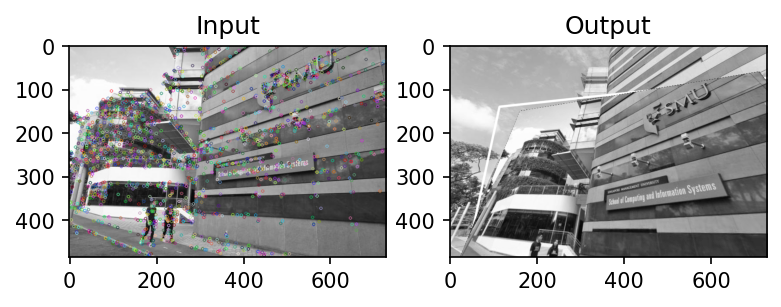

In [141]:
# https://docs.opencv.org/4.x/da/d6e/tutorial_py_geometric_transformations.html
dst = cv2.warpPerspective(img1, H_dlt, img2.shape[::-1])
dst[dst == 0] = img2[dst == 0]
plt.figure(dpi=150)
plt.subplot(121)
plt.imshow(img)
plt.title('Input')

plt.subplot(122)
plt.imshow(dst, cmap='gray')
plt.title('Output')
plt.show()